# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** Erika Wooldridge

**Dataset:** salaries.csv

**Checkpoints:**
- Checkpoint 1 (Due Feb 1): Sections 1-3
- Checkpoint 2 (Due Feb 8): Sections 4-6

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before each checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll see text cells asking you to explain your decisions, observations, and reasoning. **These written reflections are a critical part of your grade.** 

Don't just write one-word answers or skip these sections. Your reflections demonstrate:
- Your understanding of the data science process
- Your ability to communicate findings to stakeholders
- Your critical thinking about data quality and feature importance

Take time to write thoughtful, complete responses. This is what separates a good data scientist from someone who just runs code!

---

## Setup

Run this cell first to import all necessary libraries.

In [129]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

# CHECKPOINT 1 (Due: Feb 1)

---

## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

What is the expected salary of an AI/ML position based on experience, job title, and other factors that may contribute. to salary expectations?

---

### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

**Your answer:**

Knowing an individual salary is beneficial to individuals for a few reasons. If currently working in the AI/ML industry, having an understanding of salary expectations can help in salary negotiations when asking for a raise. When interviewing or accepting a job, the user knows a baseline to negotiate their salary.

---

### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

**Your answer:**

The features that will help predict a baseline salary include experience level, company size, and location." 

## Section 2: Dataset Overview

### 2.1 Load Your Data

In [130]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/salaries.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 88,584 rows, 11 columns

Column names:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


In [131]:
# TODO: View the first 5 rows of your dataframe
#
df.head(3)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Customer Success Manager,57000,EUR,60000,NL,50,NL,L
1,2025,SE,FT,Engineer,165000,USD,165000,US,0,US,M
2,2025,SE,FT,Engineer,109000,USD,109000,US,0,US,M


In [132]:
# TODO: View the last 5 rows of your dataframe
#
df.tail(5)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
88579,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
88580,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
88581,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
88582,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
88583,2021,SE,FT,Data Scientist,7000000,INR,94665,IN,50,IN,L


### 2.2 Data Types and Info

In [133]:
# TODO: Display info about your dataframe (data types, non-null counts)
#
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88584 entries, 0 to 88583
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           88584 non-null  int64 
 1   experience_level    88584 non-null  object
 2   employment_type     88584 non-null  object
 3   job_title           88584 non-null  object
 4   salary              88584 non-null  int64 
 5   salary_currency     88584 non-null  object
 6   salary_in_usd       88584 non-null  int64 
 7   employee_residence  88584 non-null  object
 8   remote_ratio        88584 non-null  int64 
 9   company_location    88584 non-null  object
 10  company_size        88584 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.4+ MB


In [134]:
# TODO: Get summary statistics for numerical columns
#
df.describe()


,work_year,salary,salary_in_usd,remote_ratio
count,88584.000000,8.858400e+04,88584.000000,88584.000000
mean,2024.034758,1.619323e+05,157567.798417,21.286011
std,0.620370,1.965317e+05,73531.373158,40.831018
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060000e+05,106097.250000,0.000000
50%,2024.000000,1.470000e+05,146307.000000,0.000000
75%,2024.000000,1.995000e+05,198600.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [135]:
# TODO: Get summary statistics for categorical columns
#
df.describe(include='object')


,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,88584,88584,88584,88584,88584,88584,88584
unique,4,4,312,26,96,90,3
top,SE,FT,Data Scientist,USD,US,US,M
freq,51596,88111,13156,83994,79705,79762,85667


### 2.3 Dataset Description

*After looking at the data above, describe your dataset in your own words.*

**Questions to answer:**
- Where did this data come from? (Kaggle link, source)
THe data came from Kaggle. The link can be found at https://www.kaggle.com/datasets/adilshamim8/salaries-for-data-science-jobs
- What does each row represent?
Each column represents the AI and ML Salaries from 2020 to 2025. The first column, 'work_year' was not used, but is represents the year of the salary. The second column, 'experience_level', is the levels. The levels are as follows: EN: Entry-level / Junior, MI: Mid-level / Intermediate, SE: Senior-level, EX. The third column, 'employment_type', will be filtered for FT (Full Time). The fourth column is 'job_title'. The specific job title include  Data Scientist, ML Engineer, AI Specialist, Research Scientist. The next two columns, 'salary' and 'salary_in_usd' are similar. The 'salary_in_usd' is the one used because it is in a standard form. The column 'employee_residence' is the country where the employee resides, 'remote_ratio' is the precentage of remote work, 'company_location' is the location of the company. The last column is the 'company_size' with S: Small (1–50 employees) M: Medium (51–500 employees)and L: Large (501+ employees).
- How many features do you have?
For the model I will be useing 8 features: experience_level, employment_type, job_title, salary_in_usd, employee_residence, remote_ratio, company_location, company_size. 
- What types of features do you have? (numerical, categorical)
The numerical features are salary_in_usd and remote_ratio. The categorical are experience_level, employment_type, job_title, employee_residence, company_location, company_size.
**Your description:**

This dataset provides an overview of comprehensive trends across Artificial Intelligence (AI), Machine Learning (ML), and Data Science from the years 2020-2025. The data is structured to evaluate the key areas of experience, job titles, company size, and salary. The dataset is used to preform Exploratory Data Analysis (EDA) to define the features that are defining the data trends and use them to determine future trends.

## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [136]:
# Define your target variable
TARGET = 'salary_in_usd'  # <-- UPDATE THIS!

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: salary_in_usd

Basic Statistics:
count     88584.000000
mean     157567.798417
std       73531.373158
min       15000.000000
25%      106097.250000
50%      146307.000000
75%      198600.000000
max      800000.000000
Name: salary_in_usd, dtype: float64


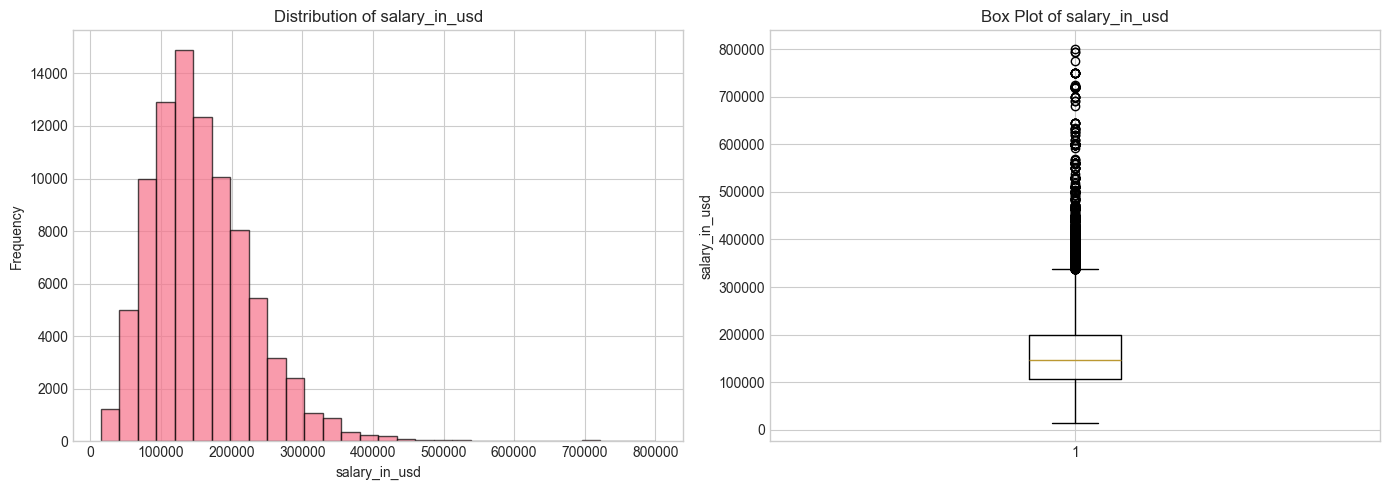


Skewness: 1.32
→ Target is highly skewed. Consider log transform in feature engineering.


In [137]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

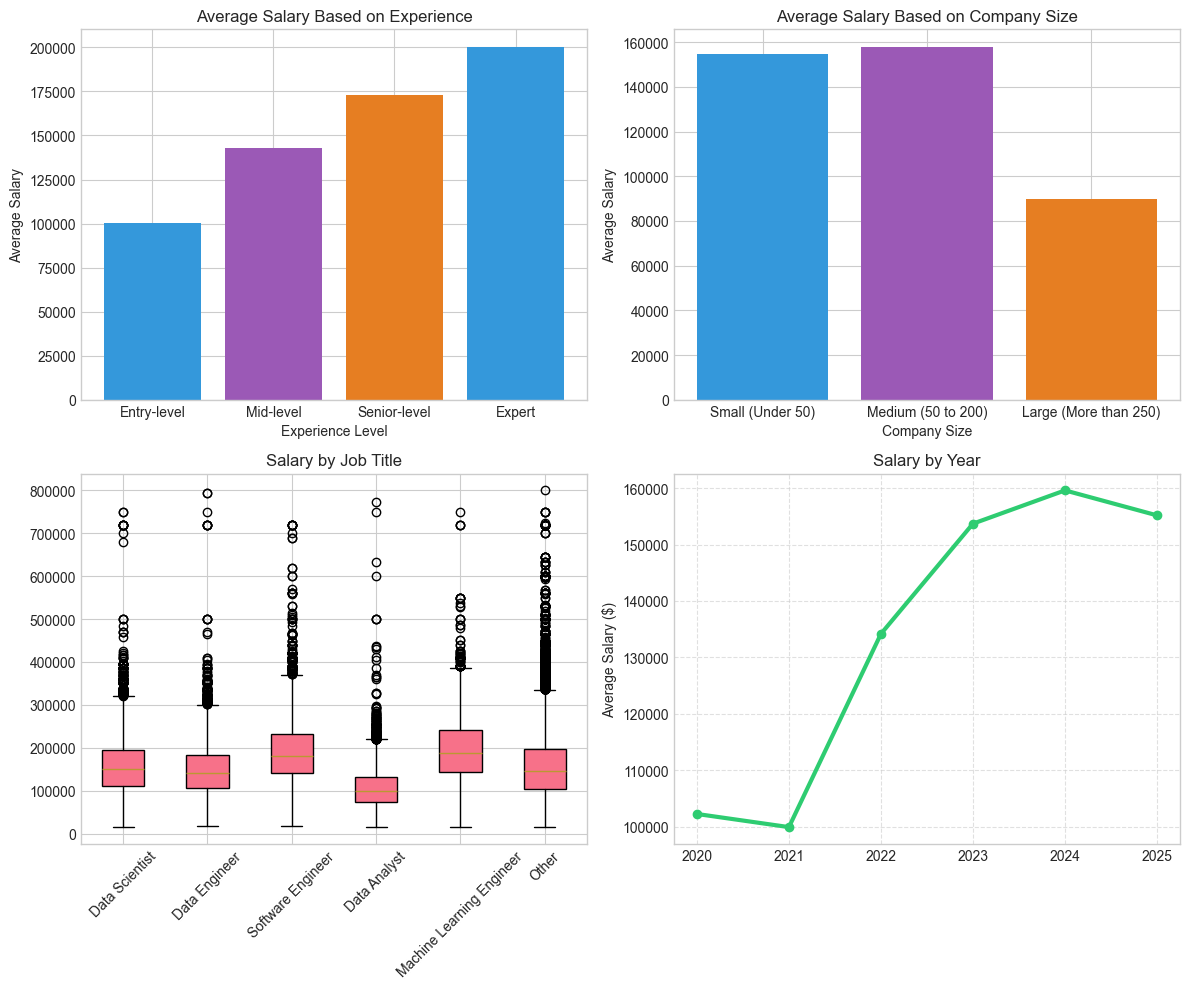

In [138]:
# Visualize survival by different features
fig, axes = plt.subplots(2,2,figsize = (12,10))

colors = {0: "#E1897F", 1: "#79813E"}

# Plot 1: Average Salary Based on Experience
exp_order = ['EN', 'MI', 'SE', 'EX']
salary_experience = df.groupby('experience_level')['salary_in_usd'].mean().reindex(exp_order)
axes[0,0].bar(salary_experience.index, salary_experience.values, color=['#3498DB', '#9B59B6', '#E67E22'])
axes[0,0].set_xlabel('Experience Level')
axes[0,0].set_ylabel('Average Salary')
axes[0,0].set_title('Average Salary Based on Experience')
axes[0,0].set_xticklabels(['Entry-level', 'Mid-level', 'Senior-level', 'Expert' ])

# Plot 2: Average Salary Based on Company Size
salary_company = df.groupby('company_size')['salary_in_usd'].mean()
axes[0,1].bar(salary_company.index, salary_company.values, color=['#3498DB', '#9B59B6', '#E67E22'])
axes[0,1].set_xlabel('Company Size')
axes[0,1].set_ylabel('Average Salary')
axes[0,1].set_title('Average Salary Based on Company Size')
axes[0,1].set_xticklabels(['Small (Under 50)','Medium (50 to 200)', 'Large (More than 250)' ])

# Plot 3: Salary Based on Job Titles
job_titles = ['Data Scientist', 'Data Engineer', 'Software Engineer', 'Data Analyst', 'Machine Learning Engineer']
salary_jobs = [df[df['job_title'] == title]['salary_in_usd'] for title in job_titles]
other_salaries = df[~df['job_title'].isin(job_titles)]['salary_in_usd']
salary_jobs.append(other_salaries)
axes[1, 0].boxplot(salary_jobs, labels=job_titles + ['Other'], patch_artist=True)
axes[1, 0].set_title('Salary by Job Title')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Salary trends for year
salary_time = df.groupby('work_year')['salary_in_usd'].mean()
axes[1,1].plot(salary_time.index, salary_time.values, marker='o', linestyle='-', color='#2ECC71', linewidth=3)
axes[1,1].set_xticks(salary_time.index)
axes[1,1].set_title('Salary by Year')
axes[1,1].set_ylabel('Average Salary ($)')
axes[1,1].grid(True, linestyle = '--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3.2 Data Quality Checks

In [139]:
# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()

duplicate_count = df.duplicated().sum()

# 2. Print the count and the percentage of duplicates
total_rows = len(df)
duplaicae_percent = (duplicate_count / total_rows) * 100
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

print(f'Duplicated rows: {duplicate_count: ,} ({duplaicae_percent: 2f})')



Duplicated rows:  44,340 ( 50.054186)


In [140]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
missing_count = df.isnull().sum()
missing_row_count = df.isnull().any(axis=1).sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
missing_precent = missing_count / len(df) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
missing_df = pd.DataFrame({'Missing Count':missing_count, 'Missing %': missing_precent})
# 4. Sort by 'Missing %' descending
missing_df= missing_df.sort_values (by='Missing %', ascending=False)
# 5. Display only columns that have missing values
missing_df = missing_df[missing_df['Missing Count']> 0]
print(f'Number of rows with missing data: {missing_row_count} \n' )
print(missing_df)
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})



Number of rows with missing data: 0 

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [141]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

✓ No missing values in the dataset!


### 3.3 Initial Observations

*Based on your initial exploration, what do you notice?*

**Questions to consider:**
- Is your target variable normally distributed or skewed?
The target variable, 'Salaries in USD' is skewed to the right. The mean is about $150,000 indicatins the majority of the employees are earning are in the lower to middle end of the spectrum. A small number of individuals are earning over $250,000.
- Are there any obvious outliers in the target?
There are a siginificant number of outliers, with maximum salary reaching $800,000. With the majority of the datapoints below $250,000, the outliers could disproportionately influence model training.
- How much missing data do you have to deal with?
The dataset is complete with zero missing values. 
- Are there any duplicate rows?
About half of the data was duplicated. To prevent data leakage and biased model performance, these duplicates should be addressed before the train/test split.
- Any surprises or interesting findings?

Surprisingly, small companies pay more than large corporations. This is likely because startups use venture capital or grants to outbid big companies for top AI talent. It makes me wonder: are these high-paying jobs stable, or are they just short-term roles to get a company off the ground? I was disapointed that half the data is duplicated. If left in, the model might overfit, essentially "memorizing" those specific rows rather than learning the general patterns.

---

## ✅ Checkpoint 1 Submission Instructions

**Congratulations!** You've completed Checkpoint 1. Before moving on, let's commit your work and submit.

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub
Open your terminal and run these commands:

```bash
# Navigate to your project folder (if not already there)
cd path/to/your/capstone-project

# Stage your notebook and data
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/raw/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 1: Problem statement and initial EDA"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 1 assignment on Canvas
2. Submit the link to your GitHub repository
3. Make sure your repo shows your latest commit!

### Step 4: Continue to Checkpoint 2
Now proceed to **Section 4** below to continue with your complete EDA, data cleaning, and feature engineering.

---

---

# CHECKPOINT 2 (Due: Feb 8)

---

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [142]:
# TODO: Get a list of numerical columns (excluding the target)
#
# Steps:
# 1. Use df.select_dtypes(include=[np.number]) to get numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# 2. Get the column names as a list with .columns.tolist()
numerical_cols= numerical_df.columns.tolist()

# 3. Remove TARGET from the list if it's in there
numerical_cols.remove(TARGET)

# 4. Print the count and list of numerical features
print(f'Count: {len(numerical_cols)}')
print(f'Features: {numerical_cols}')


Count: 3
Features: ['work_year', 'salary', 'remote_ratio']


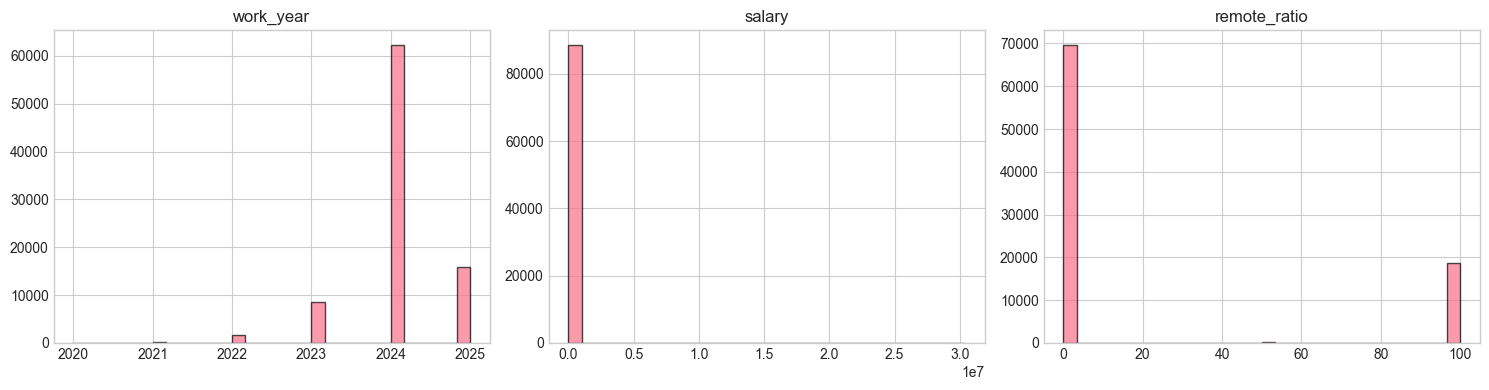

In [143]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [144]:
# TODO: Get a list of categorical columns and explore their values
#
# Steps:
# 1. Use df.select_dtypes(include=['object', 'category']) to get categorical columns
categorical_df = df.select_dtypes(include=['object', 'category'])

# 2. Get the column names as a list
categorical_cols= categorical_df.columns.tolist()

# 3. Print the count and list of categorical features
print(f'Count: {len(categorical_cols)}')
print(f'Features: {categorical_cols}')

# 4. For each categorical column, print:
#    - Number of unique values: df[col].nunique()
#    - Top 10 value counts: df[col].value_counts().head(10)
for col in categorical_cols:
    print(f'\nNumber of unique values: {df[col].nunique()} \n')
    print("Top 10 value counts: ")
    print(df[col].value_counts().head(10))
#


Count: 7
Features: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']

Number of unique values: 4 

Top 10 value counts: 
experience_level
SE    51596
MI    26748
EN     8381
EX     1859
Name: count, dtype: int64

Number of unique values: 4 

Top 10 value counts: 
employment_type
FT    88111
PT      233
CT      224
FL       16
Name: count, dtype: int64

Number of unique values: 312 

Top 10 value counts: 
job_title
Data Scientist               13156
Data Engineer                10883
Software Engineer             9596
Data Analyst                  8652
Machine Learning Engineer     6443
Engineer                      5344
Manager                       3488
Research Scientist            2553
Analyst                       2066
Applied Scientist             1778
Name: count, dtype: int64

Number of unique values: 26 

Top 10 value counts: 
salary_currency
USD    83994
GBP     2479
EUR     1559
CAD      279
INR  

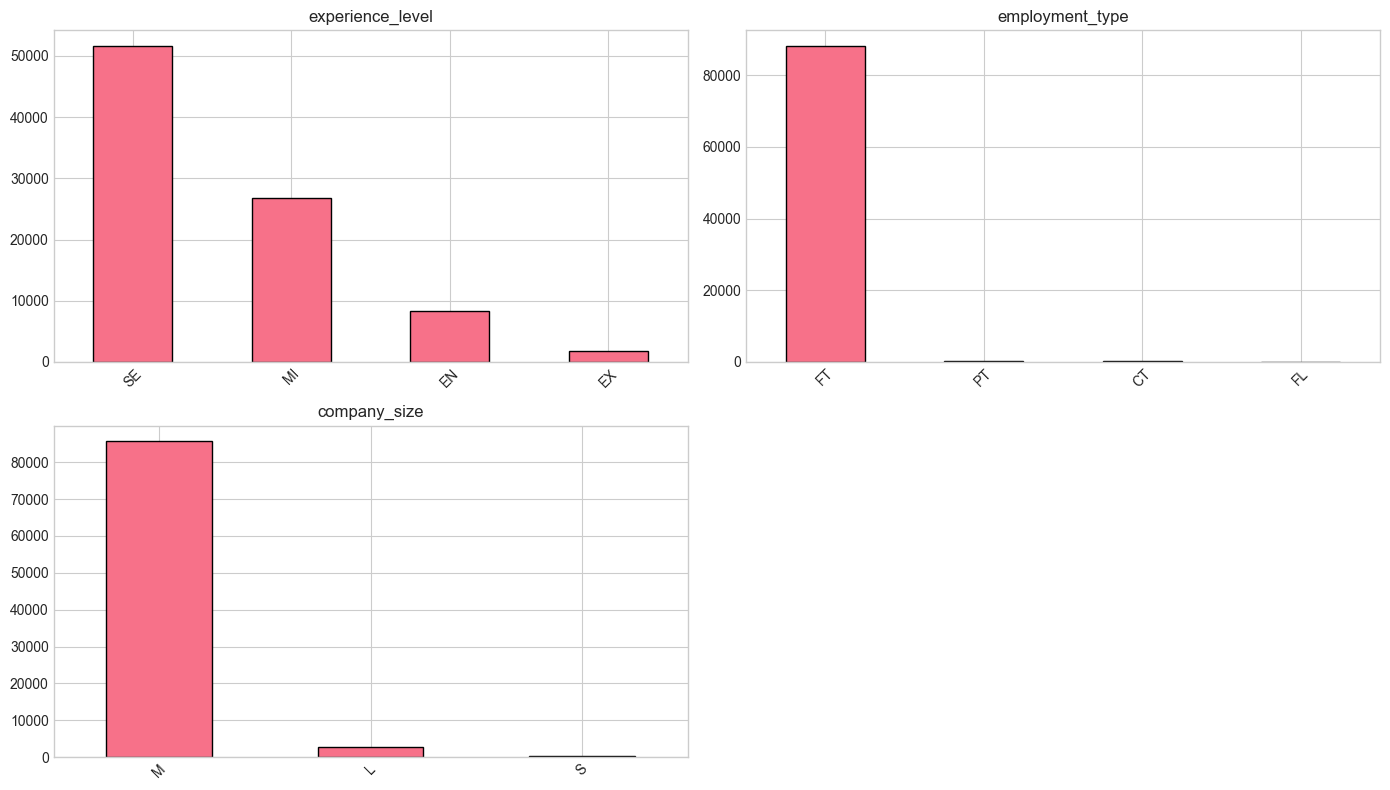

In [145]:
# Visualize categorical features (for columns with reasonable number of categories)
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 10]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(cat_cols_to_plot) == 1 else axes
    
    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")

### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

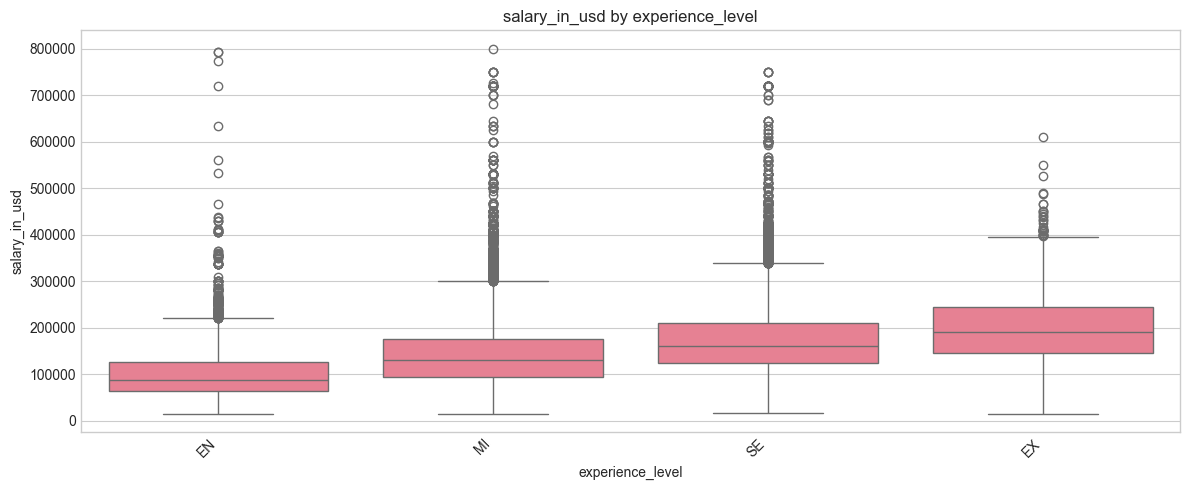


Mean salary_in_usd by experience_level:
                           mean    median  count
experience_level                                
EX                200224.101130  190000.0   1859
SE                173033.652764  161300.0  51596
MI                142708.823501  130000.0  26748
EN                100316.106908   87943.0   8381



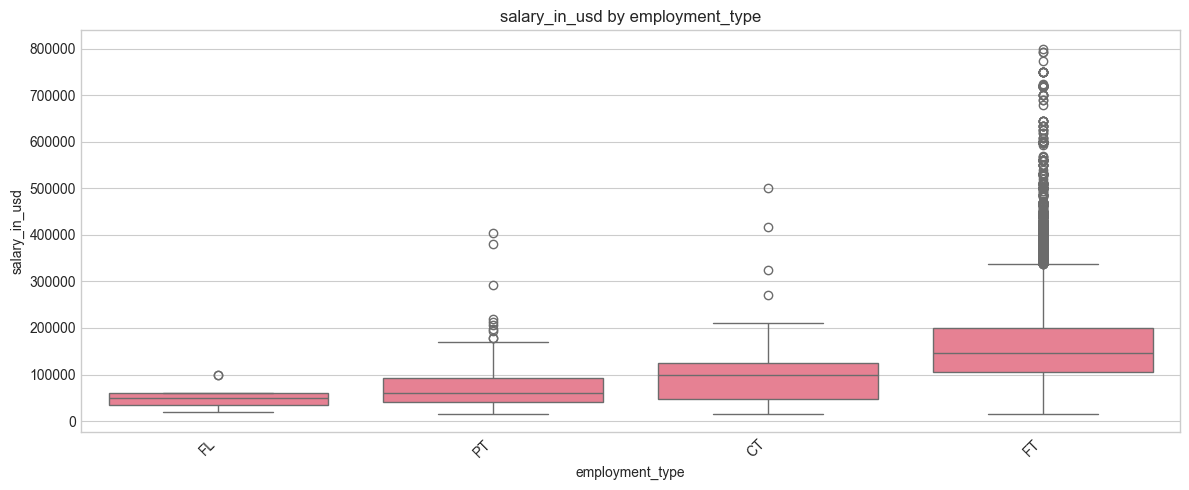


Mean salary_in_usd by employment_type:
                          mean    median  count
employment_type                                
FT               157959.297556  147000.0  88111
CT                96016.437500  100000.0    224
PT                76034.682403   60000.0    233
FL                50651.562500   50000.0     16



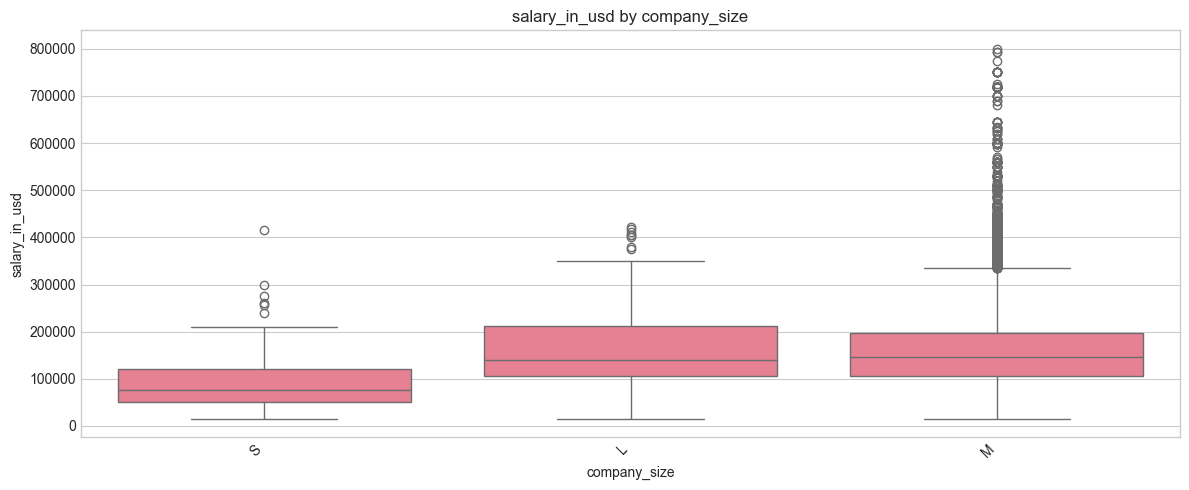


Mean salary_in_usd by company_size:
                       mean    median  count
company_size                                
M             157834.736526  147000.0  85667
L             154475.012209  139100.0   2703
S              89773.471963   76078.0    214



In [146]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 8]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))
        
        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index
        
        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

### 4.4 Correlation Analysis

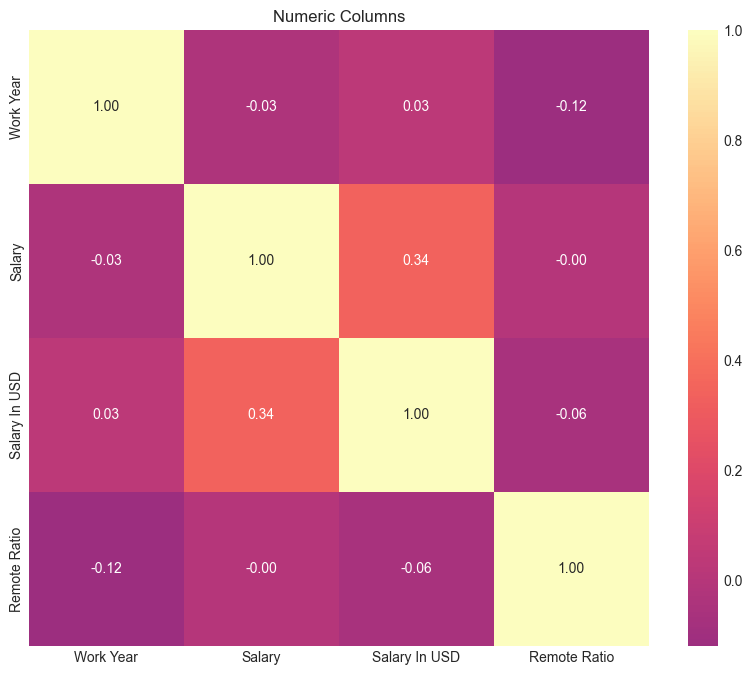

In [147]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
num_target_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# 2. Calculate the correlation matrix: df[columns].corr()
correlation_matrix = df[num_target_cols].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

plt.figure(figsize=(10, 8)) 
sns.heatmap(
    correlation_matrix, 
    annot=True,      # Show the numbers
    cmap='magma',    # Color scheme
    center=0,        # Center at 0
    fmt='.2f'        # 2 decimal places
)
plt.yticks(ticks=np.arange(4) + 0.5, labels=['Work Year', 'Salary','Salary In USD', 'Remote Ratio'])
plt.xticks(ticks=np.arange(4) + 0.5, labels=['Work Year', 'Salary','Salary In USD', 'Remote Ratio'])
plt.title('Numeric Columns')

plt.show()


In [148]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
target_correlations = correlation_matrix[TARGET]

# 2. Drop the TARGET's correlation with itself (it's always 1.0)
target_correlations = target_correlations.drop(labels=[TARGET])

# 3. Sort values in descending order
target_correlations = target_correlations.sort_values(ascending=False)

# 4. Print the correlations
print(f'Target Corolation With: {TARGET}')
print(target_correlations)

# 5. Identify strong correlations (absolute value > 0.5)
strong_correlations = target_correlations[target_correlations.abs() > 0.5]

print(f'\nStrong Corolation With: {TARGET}')
print(strong_correlations)


Target Corolation With: salary_in_usd
salary          0.341281
work_year       0.031409
remote_ratio   -0.064520
Name: salary_in_usd, dtype: float64

Strong Corolation With: salary_in_usd
Series([], Name: salary_in_usd, dtype: float64)


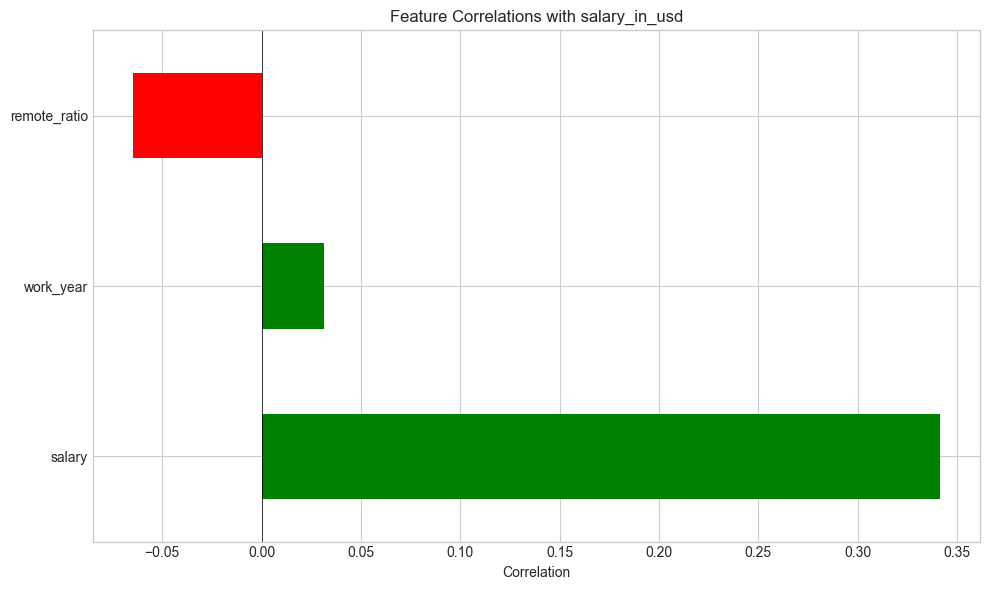

In [149]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

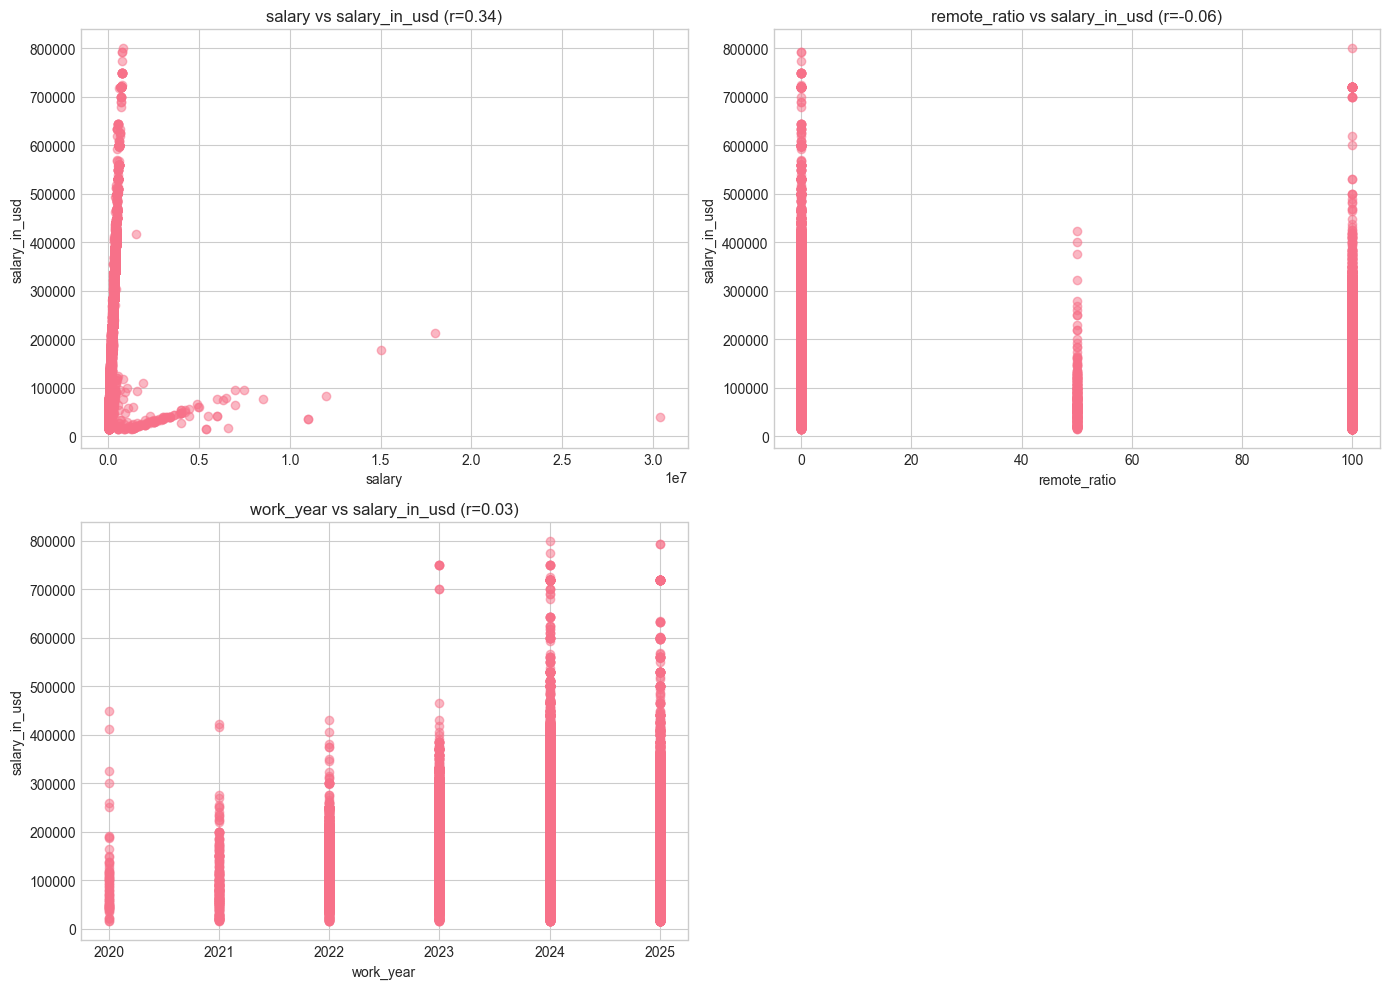

In [150]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

**What additional insights did you discover?**

[Describe any additional findings from your custom exploration]

### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target?

It looks like year, company_size, and employment_type are the main ones linked to salary, but we have to take that with a grain of salt. Since most of our data is for full-time roles and there are some wild outliers, these correlations might be a bit "noisy" and not totally representative of the whole picture.

- Which categorical features show the biggest differences in target?

Right now, remote_ratio seems to have the biggest impact on the numbers, but the data is a little messy and needs a quick cleanup first. We also have to be careful with Salary versus Salary_in_USD—the graphs can be super deceiving because they’re essentially showing the same thing  but in different ways.

- Are there any features that seem unimportant?

Honestly, work_year feels a bit redundant because its growth looks more like a reaction to general inflation since 2020 rather than a specific trend in the field. I’d also consider dropping the local currency salary column since it doesn't add much value once we have everything standardized in USD.

- Did you discover any interesting patterns or relationships?

It was actually pretty surprising to see that bigger isn't always better when it comes to paychecks! You’d expect the massive corporations to pay the most, but mid-sized companies are actually the ones hitting that $300,000+ sweet spot.

- Are there any concerns about the data (outliers, skewness, etc.)?

The big concerns are the extreme outliers and the fact that some job titles have way more data than others, which skews the results. If we want a clearer picture, we should probably lean into experience_level and company_size, as those feel like the most honest variables we have.


## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [151]:
# TODO: Create a copy of your dataframe for cleaning
#
# Why? We want to preserve the original data in case we need to go back.
# Never modify your original dataframe directly!
#
# Store in: df_clean

df_clean = df


print(f"Starting shape: {df_clean.shape}")

Starting shape: (88584, 11)


In [152]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns 
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
low_variance = [col for col in df_clean.columns 
                if df_clean[col].value_counts(normalize=True).iloc[0] > 0.95]
print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: []

2. Potential ID/URL columns: ['employee_residence']

3. High cardinality (>100 unique): ['job_title']

4. Low variance (>95% same value): ['employment_type', 'company_size']


In [153]:
# Drop columns
# TODO: Decide which columns to drop based on the analysis above
# IMPORTANT: Don't just copy all suggestions - think about each one!

columns_to_drop = [
'salary'
,'salary_currency'
,'employee_residence'
,'employment_type'
,'work_year'
]

if columns_to_drop:
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
    print(f"New shape: {df_clean.shape}")
else:
    print("No columns dropped. Update the list above if needed.")

Dropped 5 columns: ['salary', 'salary_currency', 'employee_residence', 'employment_type', 'work_year']
New shape: (88584, 6)


**Explain which columns you dropped and why:**

I dropped 'salary' and 'salary_currency' because they are redundant; they represent the same information as the target variable ('salary_in_usd') but in non-standardized formats. I also identified that 'employment_type' has extremely low variance, with 95% of the data representing 'Full-Time' roles, meaning it lacks the predictive power to explain salary differences. Work year was dropped as a recomendation from the teacher.

While 'company_size' also showed low variance, I chose to retain it because my preliminary visualizations suggest it still impacts salary outcomes. Finally, although 'job_title' currently has high cardinality, I am keeping it for future feature engineering to group these titles into broader, more meaningful categories.

### 5.2 Handle Duplicate Rows

In [154]:
# TODO: Remove duplicate rows from df_clean
#
# Steps:
# 1. Store the row count before: len(df_clean)
before_count = len(df_clean)
# 2. Use df_clean.drop_duplicates() to remove duplicates (assign back to df_clean)
df_clean = df_clean.drop_duplicates()
# 3. Store the row count after
after_count = len(df_clean)
# 4. Print how many duplicates were removed
print(f'Count before dropping duplicates: {before_count}')
print(f'Count after dropping duplicates: {after_count}')


Count before dropping duplicates: 88584
Count after dropping duplicates: 38091


### 5.3 Handle Missing Values

In [155]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
Series([], dtype: int64)


In [156]:
# Handle missing values
# TODO: Add your missing value handling code here
# 
# STRATEGIES:
# - Numerical columns: use median (robust to outliers) or mean
# - Categorical columns: use mode or 'Unknown'
# - Drop rows if missing target variable
#
# Examples:
# df_clean['column'] = df_clean['column'].fillna(df_clean['column'].median())
# df_clean['column'] = df_clean['column'].fillna('Unknown')
# df_clean = df_clean.dropna(subset=[TARGET])  # Don't predict with missing target!

print('No missing data for this set')



No missing data for this set


In [157]:
# Verify missing values are handled
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print("\n⚠️ Still have missing values in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning: 0


**Explain your missing value strategy:**

This data set was not missing any values. This section was not needed.

### 5.4 Handle Outliers (if needed)

In [158]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
salary_in_usd: 899 outliers (2.4%) | bounds: [-49843.75, 333906.25]


In [159]:
# Handle outliers (if needed)
# TODO: Add your outlier handling code here if needed
#
# STRATEGIES:
# - Remove rows with outliers (be careful - losing data)
# - Cap/clip values at bounds
# - Keep them (if they're valid data points)
#
# Examples:
# df_clean = df_clean[df_clean['price'] > 0]  # Remove invalid prices
# df_clean = df_clean[df_clean['price'] < 500000]  # Remove extreme prices
# df_clean['column'] = df_clean['column'].clip(lower=0, upper=upper_bound)

df_clean = df_clean[df_clean['salary_in_usd'] < 333906.25]  



**Explain your outlier handling strategy (or why you kept them):**

Outliers were removed using the Interquartile Range (IQR) method. Although high-earning roles are common within the AI and ML sectors, these 899 observations represented only 2% of the total dataset. Removing these extreme values prevents the model from being skewed, ensuring it remains optimized to predict typical salary ranges across the remaining 43,000+ data points.

### 5.5 Data Type Corrections

In [160]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
experience_level    object
job_title           object
salary_in_usd        int64
remote_ratio         int64
company_location    object
company_size        object
dtype: object


In [161]:
# Fix any data type issues
# TODO: Add your data type corrections here if needed
#
size_map = {'S': 0, 'M': 1, 'L': 2}
experince_map = {'EN': 1, 'MI':2, 'SE':3, 'EX':4}



## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [162]:
# Create new features
# TODO: Add your feature engineering code here
#
# Examples:
# df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft']
# df_clean['log_price'] = np.log1p(df_clean['price'])
# df_clean['age'] = 2026 - df_clean['year']

# Map Company sizes

df_clean['company_size'] = df_clean['company_size'].map(size_map)
df_clean['experience'] = df_clean['experience_level'].map(experince_map)



### 6.2 Encode Categorical Variables

**Explain your new features:**

[Describe what features you created and why they might help predict the target]

In [163]:
# TODO: Identify categorical columns that need encoding
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols

#Location Logic
df_clean['company_location'] = np.where(df_clean['company_location'] == 'US', 'US', 'Other')


#Job Title Logic (Updated to use df_clean)
top_jobs = ['Data Scientist', 'Data Engineer', 'Software Engineer', 'Data Analyst', 'Machine Learning Engineer']
df_clean.loc[~df_clean['job_title'].isin(top_jobs), 'job_title'] = 'Other'


In [164]:
# Encode categorical variables
# TODO: Add your encoding code here
#
# STRATEGIES:
# - One-hot encoding: for low cardinality (< 10 unique values)
# - Label encoding: for ordinal data or high cardinality
# - Target encoding: advanced technique (be careful of data leakage)
#
# Examples:
# One-hot encoding:
# df_clean = pd.get_dummies(df_clean, columns=['category_col'], drop_first=True)
#
# Label encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['encoded_col'] = le.fit_transform(df_clean['category_col'])

# YOUR CODE HERE:
df_clean = pd.get_dummies(df_clean, columns=['experience_level', 'company_location', 'job_title'], dtype=int)



**Explain your encoding strategy:**

[Describe what encoding methods you used and why]
By grouping everything that isn't "US" or a "Top 5 Job" into an 'Other' category, you're fixing a major data headache. If you have 50 different countries or 100 random job titles with only one person in each, it confuses the model; grouping them helps the model focus on the high-traffic areas that actually drive salary trends. By mapping them to numbers (like 0, 1, 2), you’re creating Ordinal Data, which tells the model there is a specific rank or "level up" progression in company size and expertise. One-hot encoding transforms categorical names into a series of binary columns so that the model can process them numerically without incorrectly assuming there is a ranked order or "score" between different job titles.

### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
We’re looking at market demand and the cost of living, acknowledging that a "Senior" rank in the tech world carries specific weight and pay standards. It’s about understanding that certain specialist roles are high-value targets in the current economy.

- Are there any feature interactions that might be predictive?
The intersection of Experience Level and Company Size is a key lead, as senior staff at mid-sized firms often see unique pay spikes. We should also track how Job Title and Location work together to dictate the going rate.

- Can you create meaningful groups or categories?
We’ve consolidated the outliers by grouping locations into "US" vs. "Other" and sorting job titles into broader "buckets" like Engineering or Analytics. This clears the noise so we can focus on the primary suspects driving the salary data.

- Would polynomial features help capture non-linear relationships?
Polynomials allow the model to follow that curve rather than trying to force a linear narrative.

### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [165]:
# TODO: Identify numerical features and check their ranges
#
# Steps:
# 1. Get numerical columns from df_clean (excluding TARGET)
numerical_features= df_clean.columns.tolist()
numerical_features.remove(TARGET)

# 2. For each column, print the min, max, and range
#
# This helps you understand if features need scaling (different scales = need scaling)

for col in numerical_features:
    col_min = df_clean[col].min()
    col_max = df_clean[col].max()
    print(f"{col} | Min: {col_min}, Max: {col_max}, Range: {col_max - col_min}")


remote_ratio | Min: 0, Max: 100, Range: 100
company_size | Min: 0, Max: 2, Range: 2
experience | Min: 1, Max: 4, Range: 3
experience_level_EN | Min: 0, Max: 1, Range: 1
experience_level_EX | Min: 0, Max: 1, Range: 1
experience_level_MI | Min: 0, Max: 1, Range: 1
experience_level_SE | Min: 0, Max: 1, Range: 1
company_location_Other | Min: 0, Max: 1, Range: 1
company_location_US | Min: 0, Max: 1, Range: 1
job_title_Data Analyst | Min: 0, Max: 1, Range: 1
job_title_Data Engineer | Min: 0, Max: 1, Range: 1
job_title_Data Scientist | Min: 0, Max: 1, Range: 1
job_title_Machine Learning Engineer | Min: 0, Max: 1, Range: 1
job_title_Other | Min: 0, Max: 1, Range: 1
job_title_Software Engineer | Min: 0, Max: 1, Range: 1


### 6.5 Final Sanity Checks

In [166]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 37,192 rows, 16 columns
   (Started with 88,584 rows, 11 columns)

2. Missing values: 0

3. Duplicate rows: 11088

4. Target variable 'salary_in_usd':
   - Min: 15000.00
   - Max: 333900.00
   - Mean: 143574.04

5. Data types:
   - Numerical: 16
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [167]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (37192, 16)

Columns (16):
['salary_in_usd', 'remote_ratio', 'company_size', 'experience', 'experience_level_EN', 'experience_level_EX', 'experience_level_MI', 'experience_level_SE', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Data Engineer', 'job_title_Data Scientist', 'job_title_Machine Learning Engineer', 'job_title_Other', 'job_title_Software Engineer']

Data types:
salary_in_usd                          int64
remote_ratio                           int64
company_size                           int64
experience                             int64
experience_level_EN                    int64
experience_level_EX                    int64
experience_level_MI                    int64
experience_level_SE                    int64
company_location_Other                 int64
company_location_US                    int64
job_title_Data Analyst                 int64
job_title_Data Engineer                int64
job_title_Data 

In [168]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv


### 6.7 Feature Engineering Summary

*Summarize all the data cleaning and feature engineering you performed.*

**Checklist:**
- [ ] Columns dropped (with justification)
- [ ] Duplicate rows removed
- [ ] Missing values handled
- [ ] Outliers addressed (or documented why not)
- [ ] Data types corrected
- [ ] New features created (if applicable)
- [ ] Categorical variables encoded
- [ ] Data saved to processed folder

**Summary of changes:**

[Write a thorough summary of everything you did to clean and transform the data]

**Final feature list for modeling:**

[List all the features you'll use in your models]

---

## ✅ Checkpoint 2 Submission Instructions

**Congratulations!** You've completed Checkpoint 2 (EDA, Data Cleaning, and Feature Engineering).

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub

```bash
# Stage your changes
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/processed/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 2: EDA, data cleaning, and feature engineering"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 2 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

You're ready to move on to **Notebook 02: Regression Model**!

In that notebook, you'll:
1. Load your cleaned data
2. Split into train/test sets
3. Build and evaluate regression models
4. Save your best model

---